# 06 — Corporate Climate Credibility Score (CCCS) composite + quadrant assignment

**Project:** Corporate Climate Credibility Audit — power-sector Proof-of-Concept (POC)

**Author:** Souvik Mandal (drsouvikmandal@gmail.com)

**Notebook role.** This notebook combines three independently-constructed per-parent signals into a single headline credibility score, then assigns each cohort parent to one of four quadrants:

- **Pledge Quality Score (PQS)** — the *Talk* axis. Measures how concrete and verifiable each parent's public climate pledges are. Constructed in notebook 05 by scoring each parent's disclosure corpus (Science Based Targets initiative (SBTi) targets + Net Zero Tracker (NZT) structured fields + U.S. Securities and Exchange Commission (SEC) 10-K filings Items 1A and 7) against a 5-criteria rubric using dual-LLM scoring (Claude Sonnet 4.6 + GPT-4o, both at `temperature=0`).
- **EPA Performance Score (EPS)** — the *Walk* axis. Measures each parent's actual decarbonization trajectory over the U.S. Environmental Protection Agency Greenhouse Gas Reporting Program (EPA GHGRP) panel period (2011–2023). Constructed here from per-parent ordinary-least-squares trajectory slopes computed in notebook 01.
- **Satellite Cross-Validation Score (SCVS)** — the *Verify* axis. Measures the agreement between each parent's reported GHGRP emissions and the independent Climate TRACE satellite-derived estimate. Constructed here from per-parent random intercepts of the Linear Mixed-Effects (LME) model fit in notebook 03 §3.6.

The composite Corporate Climate Credibility Score (CCCS) is the weighted geometric mean of the three axes. Each parent is then placed in the 2×2 quadrant defined by Pledge Quality Score × EPA Performance Score, with the Satellite Cross-Validation Score encoded as color.

## What this notebook delivers

| Section | What it produces |
|---|---|
| 1 | Load PQS scores (notebook 05), trajectory slopes (notebook 01), and LME random intercepts (notebook 03 §3.6); merge with the 50-parent cohort |
| 2 | Construct EPA Performance Score (EPS) from trajectory slopes via within-cohort percentile rank |
| 3 | Construct Satellite Cross-Validation Score (SCVS) from "LME random intercept" via within-cohort percentile rank |
| 4 | Compute Corporate Climate Credibility Score (CCCS) composite via weighted geometric mean; carry NaN for Talk-NA parents; provide a partial composite column for them |
| 5 | 2×2 quadrant assignment + headline figure |
| 6 | Sensitivity analysis: how do rankings change under 6 alternative weight schemes? |
| 7 | Save deliverables (`cohort_cccs.csv`, `cohort_cccs_components.csv`, `cohort_cccs_rank_stability.csv`) |
| 8 | Summary of results |

## Significance of this notebook

The three axes — Pledge Quality, EPA Performance, Satellite Cross-Validation — by themselves answer narrow questions:

- *What did the company say it would do?* (notebook 05's Pledge Quality Score)
- *What does the regulator's record show?* (notebook 01's EPA emissions trajectory)
- *What does the independent satellite-derived estimate show?* (notebook 03's Climate TRACE vs GHGRP analysis)

Each axis is interesting individually but incomplete. The accountability question stakeholders actually want answered is sharper: **for each parent company, are these three signals telling a consistent story?**

A parent can score high on one axis and low on others — and which combination they fall into determines whether they should be classified as a *Credible Leader*, a *Greenwasher*, a *Quiet Achiever*, or a *Laggard*. The composite score is the synthesis that lets us answer this question on a single number, while the 2×2 quadrant chart lets us answer it visually.

The two-by-two quadrant chart in §5 is the headline visualization for the working paper: it places every cohort parent on the *Talk* (Pledge Quality) × *Walk* (EPA Performance) plane, color-codes the independent *Verify* (Satellite Cross-Validation) signal, and shows at a glance whether the parents whose pledges and reported emissions look credible *also* survive an independent satellite check.

## Methodology — choices I made and rationale

### EPA Performance Score (EPS) — rank-based percentile

Each parent has a 2011–2023 trajectory slope (in % change per year of EPA GHGRP reported emissions, normalized by parent baseline) computed in notebook 01 via ordinary least squares with bootstrap confidence intervals. We map these slopes to an EPS in [0, 100] by **percentile rank within the cohort**: the parent with the most negative slope (most aggressive decarbonization) receives EPS ≈ 100; the parent with the most positive slope receives EPS ≈ 0; the median parent receives EPS = 50.

**Why percentile rank, and not absolute % decline or standardized slope?** Three reasons:

1. *Cohort-relative ranking is what the audience cares about.* The question is "how does this company compare to its peers", not "how big is its absolute change". A parent that cut emissions by 30% over 13 years is impressive in isolation; the more useful framing for a credibility audit is "where do they rank against the other 49 in the cohort".
2. *Rank is robust to merger/divestiture outliers.* Several cohort parents (Vistra, Talen Energy spinoff, NRG asset sales) have slopes contaminated by one-time bookkeeping changes that an absolute-% metric would treat as real decarbonization. Rank-within-cohort downweights these.
3. *The median = 50 anchor makes the score directly interpretable.* "Above 50" means above-cohort-median performer. No re-scaling decisions are needed.

### Satellite Cross-Validation Score (SCVS) — rank-based percentile on |random intercept|

Notebook 03 §3.3 fit the Linear Mixed-Effects model `log(GHGRP) ~ log(Climate TRACE) + log(CEMS load) + (1|parent) + (1|facility)` and §3.6 extracted a per-parent random intercept. The magnitude |intercept| measures how much each parent's Climate TRACE-vs-GHGRP relationship deviates from the cohort-wide pattern after controlling for operational scale (CEMS-measured gross load).

We map |intercept| to SCVS in [0, 100] by **percentile rank**: the parent with the smallest |intercept| (best Climate TRACE-vs-GHGRP agreement) receives SCVS ≈ 100; the parent with the largest |intercept| receives SCVS ≈ 0.

**Why percentile rank and not an inverse-magnitude formula?** Symmetry with EPS — using the same construction method across all three axes makes them apples-to-apples comparable, which matters when we compute their geometric mean. Also rank-based scoring is robust to the worst-disagreement parent dominating a formula's denominator.

### Composite construction — weighted geometric mean

```
CCCS = (PQS ^ w_PQS) × (EPS ^ w_EPS) × (SCVS ^ w_SCVS)    where w_PQS + w_EPS + w_SCVS = 1
```

Default weights are **0.2 PQS / 0.4 EPS / 0.4 SCVS** (locked in the project workplan §3). The choice of **geometric** mean rather than arithmetic is deliberate: a low score on any single axis pulls the composite down disproportionately. A parent cannot offset a PQS of 10 with an EPS of 90 — the geometric mean penalizes the imbalance. This reflects the framework's core conviction that **credibility requires consistency across the three signals, not strength on one in compensation for weakness on another**.

### Talk-NA handling — carry NaN, plus a partial-composite column

Notebook 05 produced PQS for 26 of the 50 cohort parents; the remaining 24 are "Talk-NA" — cooperatives, public-power authorities, private-equity-owned holding companies, and government entities with no public disclosure source we can access. For these, the Talk axis is *genuinely unmeasured*, not zero.

Our handling is two-pronged:

1. **The `pqs_composite` column carries `NaN`** for Talk-NA parents. Their full `cccs_composite` is also `NaN`. They appear in the quadrant chart in a separate band along the EPA Performance axis (with Talk = unmeasured), color-coded by Satellite Cross-Validation Score so the missing-Talk status is visible rather than hidden.
2. **A separate `cccs_partial_composite` column** is computed as the geometric mean of (EPS, SCVS) only, with weights renormalized to 0.5 / 0.5. This gives a partial-credibility signal for Talk-NA parents that downstream consumers (notebook 07's dashboard) can display alongside the full composite if they choose.

**Why not impute the missing PQS at cohort median?** Imputation would invent a score we don't have. For a credibility-framework deliverable that argues for methodological honesty, that is the wrong tradeoff. The partial composite is the more defensible alternative.

### Sensitivity analysis — six weight schemes

The default weights (0.2 / 0.4 / 0.4) reflect a specific stance: Walk and Verify dominate Talk because of the 74% S&P-500 restatement rate documented by Cohen, Rouen & Sachdeva (2026, *Nature Climate Change*). But different stakeholders would reasonably pick different weights. For this task, I am testing six schemes to see which parents are robustly classified and which are weight-dependent:

| Scheme | PQS | EPS | SCVS | Whose preference this reflects |
|---|---:|---:|---:|---|
| Default | 0.20 | 0.40 | 0.40 | Workplan-locked; Walk and Verify dominate Talk |
| Equal | 0.33 | 0.33 | 0.33 | Agnostic / democratic prior across the three axes |
| Action-heavy | 0.10 | 0.45 | 0.45 | Penalize talk-only firms beyond the default |
| Talk-heavy | 0.40 | 0.30 | 0.30 | Pledge-watcher / corporate-strategy weighting |
| Walk-heavy | 0.20 | 0.60 | 0.20 | EPA / regulator-perspective weighting |
| Verify-heavy | 0.20 | 0.20 | 0.60 | Short-seller / post-GHGRP-world weighting |

For each parent we report their CCCS rank under each scheme and whether they remain in the top quartile / bottom quartile across all schemes (a stability flag). The deliverable `cohort_cccs_rank_stability.csv` makes this auditable.

## 0. Environment

In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT   = Path("/Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIG_DIR        = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility seed
RNG_SEED = 20260524
np.random.seed(RNG_SEED)

# Visual defaults
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

# Default composite weights (workplan §3)
W_DEFAULT = {"pqs": 0.20, "eps": 0.40, "scvs": 0.40}
assert abs(sum(W_DEFAULT.values()) - 1.0) < 1e-9

print(f"Project root:    {PROJECT_ROOT}")
print(f"Data processed:  {DATA_PROCESSED}")
print(f"Figures out:     {FIG_DIR}")
print(f"Default weights: PQS={W_DEFAULT['pqs']}  EPS={W_DEFAULT['eps']}  SCVS={W_DEFAULT['scvs']}")

Project root:    /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task
Data processed:  /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/data/processed
Figures out:     /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/outputs/figures
Default weights: PQS=0.2  EPS=0.4  SCVS=0.4


> **Note on Plotly dependency.** Section 5's headline figure uses [Plotly](https://plotly.com/python/) for interactivity (hover tooltips, zoom, pan, legend toggling). If your environment does not already have Plotly installed, that cell will raise `ModuleNotFoundError`. Two ways to resolve:
>
> 1. **Uncomment and Run the next cell**, which installs Plotly into the current Jupyter kernel via `%pip install plotly`. This is a one-time setup; you can re-run it safely (pip is a no-op when Plotly is already present).
> 2. **Install from your terminal**: `pip install plotly` then restart the notebook kernel.
>
> If you prefer to skip the Plotly dependency entirely, the §5 cell has a matplotlib backup (in the cell immediately after the Plotly chart) that produces a static PNG version of the same chart with no extra dependencies.
>
> All dependencies for this project are listed in `requirements.txt` at the project root. To install everything at once: `pip install -r requirements.txt`.

In [ ]:
# Install Plotly for the §5 interactive chart.
# Skip this cell if you've already installed Plotly (e.g., via `pip install -r requirements.txt`).
#%pip install -q plotly

## 1. Load inputs

We assemble a per-parent dataframe by left-joining the 50-parent cohort against the three upstream deliverables. Coverage gaps (Talk-NA parents missing from notebook 05's PQS; parents missing from notebook 03's LME sample) are preserved as `NaN` and reported.

In [ ]:
# Load the four inputs
cohort   = pd.read_csv(DATA_PROCESSED / "cohort_top50.csv")
pqs      = pd.read_csv(DATA_PROCESSED / "cohort_pqs.csv")
slopes   = pd.read_csv(DATA_PROCESSED / "per_parent_trajectory_slopes.csv")
lme_ints = pd.read_csv(DATA_PROCESSED / "lme_per_parent_intercepts.csv")

print(f"cohort_top50:                  {len(cohort)} parents")
print(f"cohort_pqs (scored):           {(pqs['status']=='scored').sum()} parents (of {len(pqs)} rows)")
print(f"per_parent_trajectory_slopes:  {len(slopes)} parents")
print(f"lme_per_parent_intercepts:     {len(lme_ints)} parents")

# Restrict PQS to the scored rows only; Talk-NA parents will surface as NaN after merge
pqs_scored = pqs[pqs["status"] == "scored"][["parent_name", "pqs_composite"]].copy()

# Merge into a single per-parent dataframe, keyed on parent_name
df = (cohort[["parent_name", "rank", "attributed_co2e"]]
      .merge(pqs_scored, on="parent_name", how="left")
      .merge(slopes[["parent_name", "pct_per_yr"]], on="parent_name", how="left")
      .merge(lme_ints, on="parent_name", how="left"))

print(f"\nMerged dataframe: {len(df)} parents x {df.shape[1]} columns")
print(f"\nCoverage after merge:")
print(f"  PQS present:               {df['pqs_composite'].notna().sum():2d} / {len(df)}  (Talk-NA: {df['pqs_composite'].isna().sum()})")
print(f"  trajectory slope present:  {df['pct_per_yr'].notna().sum():2d} / {len(df)}")
print(f"  LME parent_intercept:      {df['parent_intercept'].notna().sum():2d} / {len(df)}")

# Show any parents missing slope or LME intercept (defensive — should be rare)
missing_slope = df[df["pct_per_yr"].isna()]
missing_lme   = df[df["parent_intercept"].isna()]
if len(missing_slope):
    print(f"\nParents missing trajectory slope ({len(missing_slope)}):")
    print(missing_slope[["rank","parent_name"]].to_string(index=False))
if len(missing_lme):
    print(f"\nParents missing LME intercept ({len(missing_lme)}):")
    print(missing_lme[["rank","parent_name"]].to_string(index=False))

cohort_top50:                  50 parents
cohort_pqs (scored):           26 parents (of 26 rows)
per_parent_trajectory_slopes:  50 parents
lme_per_parent_intercepts:     48 parents

Merged dataframe: 50 parents x 6 columns

Coverage after merge:
  PQS present:               26 / 50  (Talk-NA: 24)
  trajectory slope present:  50 / 50
  LME parent_intercept:      48 / 50

Parents missing LME intercept (2):
 rank             parent_name
   49 MARATHON PETROLEUM CORP
   50        EXXON MOBIL CORP


## 2. EPA Performance Score (EPS) construction

We rank each parent on `pct_per_yr` (the percentage-change-per-year of their EPA GHGRP reported emissions over the 13-year panel) **in descending order**, so the most negative value (most aggressive decarbonization) gets the highest rank. Mapped to 0–100, this gives EPS where 100 = fastest decarbonizer in the cohort, ~50 = median, ~0 = worst (largest emissions increase or smallest decrease).

In [15]:
# Rank by pct_per_yr descending — most negative (best decarbonization) gets highest pct rank
# pandas .rank(pct=True, ascending=False) returns values in (0, 1] where smallest input gets 1.0
df["eps_score"] = df["pct_per_yr"].rank(pct=True, ascending=False) * 100

# Diagnostic printout
eps_summary = df[["parent_name", "pct_per_yr", "eps_score"]].dropna().sort_values("eps_score", ascending=False)
print(f"EPS construction (rank-based percentile on pct_per_yr, descending):")
print(f"  parents scored: {df['eps_score'].notna().sum()}")
print(f"  EPS range:      [{df['eps_score'].min():.1f}, {df['eps_score'].max():.1f}]")
print(f"  EPS median:     {df['eps_score'].median():.1f}\n")

EPS construction (rank-based percentile on pct_per_yr, descending):
  parents scored: 50
  EPS range:      [2.0, 100.0]
  EPS median:     51.0



In [14]:
eps_summary

# `pct_per_yr` is the percentage-change-per-year of their EPA GHGRP reported emissions over the 13-year panel. A more negative value is better (faster decarbonization). A positive value means their reported emissions are increasing over time.

,parent_name,pct_per_yr,eps_score
30,TALEN ENERGY CORP,-9.684833,100.0
40,OGE ENERGY CORP,-8.341914,98.0
14,NRG ENERGY INC,-7.675596,96.0
43,TECO ENERGY INC,-6.426054,94.0
7,US GOVERNMENT,-5.970283,92.0
4,AMERICAN ELECTRIC POWER CO INC,-5.499860,90.0
29,PINNACLE WEST CAPITAL CORP,-4.852622,88.0
12,EVERGY INC,-4.683977,86.0
47,ARKANSAS ELECTRIC COOPERATIVE CORP,-3.992235,84.0
23,SOUTH CAROLINA PUBLIC SERVICE AUTHORITY,-3.919370,82.0


## 3. Satellite Cross-Validation Score (SCVS) construction

We take the magnitude |parent_intercept| from notebook 03 §3.6's LME (Linear Mixed-Effects model) and rank in descending order on `-|intercept|`, so the smallest |intercept| (best Climate TRACE-vs-GHGRP agreement) gets the highest rank. Mapped to 0–100, SCVS where 100 = closest agreement in the cohort, ~50 = median, ~0 = largest disagreement.

The sign of the intercept (positive = Climate TRACE over-reports the parent; negative = under-reports) is preserved in `parent_intercept` for downstream auditing but is not used in the SCVS magnitude itself — disagreement-in-either-direction reduces credibility symmetrically.

In [17]:
# Compute |intercept| and rank descending on -|intercept|
df["abs_intercept"] = df["parent_intercept"].abs()
df["scvs_score"]    = (-df["abs_intercept"]).rank(pct=True, ascending=False) * 100
# Equivalent: df["abs_intercept"].rank(pct=True, ascending=False) * 100, but spelt out for clarity

# Diagnostic printout
scvs_summary = df[["parent_name", "parent_intercept", "abs_intercept", "scvs_score"]].dropna(subset=["scvs_score"]).sort_values("scvs_score", ascending=False)
print(f"SCVS construction (rank-based percentile on |LME parent intercept|):")
print(f"  parents scored:        {df['scvs_score'].notna().sum()}")
print(f"  SCVS range:            [{df['scvs_score'].min():.1f}, {df['scvs_score'].max():.1f}]")
print(f"  SCVS median:           {df['scvs_score'].median():.1f}")
print(f"  |intercept| range:     [{df['abs_intercept'].min():.3f}, {df['abs_intercept'].max():.3f}]\n")

SCVS construction (rank-based percentile on |LME parent intercept|):
  parents scored:        48
  SCVS range:            [2.1, 100.0]
  SCVS median:           51.0
  |intercept| range:     [0.003, 0.294]



In [16]:
scvs_summary

# Satellite Cross-Validation (Climate TRACE vs GHGRP) agreement across the cohort.
# The LME parent_intercept captures each parent's average disagreement between
# Climate TRACE's satellite-derived emissions estimate and GHGRP-reported
# emissions, after controlling for operational scale via the CEMS gross-load
# covariate. (CEMS is the *covariate* in the regression, not one of the two
# compared sources.) A smaller |intercept| means closer Climate TRACE-vs-GHGRP
# agreement = higher Satellite Cross-Validation Score (SCVS); a larger
# |intercept| means larger systematic disagreement = lower SCVS.

,parent_name,parent_intercept,abs_intercept,scvs_score
5,CPN MANAGEMENT LP,-0.294495,0.294495,100.000000
6,NEXTERA ENERGY INC,-0.194346,0.194346,97.916667
12,EVERGY INC,0.183228,0.183228,95.833333
31,ARCLIGHT ENERGY PARTNERS FUND VII LP,-0.128185,0.128185,93.750000
27,"LS Power Development, LLC",-0.116907,0.116907,91.666667
4,AMERICAN ELECTRIC POWER CO INC,0.114674,0.114674,89.583333
34,CONSTELLATION ENERGY CORP,-0.113871,0.113871,87.500000
3,BERKSHIRE HATHAWAY INC,0.089046,0.089046,85.416667
0,Vistra Corp,-0.077629,0.077629,83.333333
24,ALLIANT ENERGY CORP,0.077017,0.077017,81.250000


## 4. Corporate Climate Credibility Score (CCCS) composite

Two composite columns are computed:

- `cccs_composite` — the full weighted geometric mean across all three axes (PQS, EPS, SCVS) using the default weights 0.2 / 0.4 / 0.4. Returns `NaN` for Talk-NA parents (PQS unavailable).
- `cccs_partial_composite` — for Talk-NA parents, the weighted geometric mean of (EPS, SCVS) only with renormalized weights 0.5 / 0.5. For scored parents this column also reports the EPS×SCVS partial composite, which can be useful for the dashboard to show "what their score would be without the Talk axis."

The geometric-mean formula is implemented in log space for numerical stability:
```
log(CCCS) = w_PQS · log(PQS) + w_EPS · log(EPS) + w_SCVS · log(SCVS)
```
A score of 0 on any axis would map to `log(0) = -inf`, but because EPS and SCVS are constructed via percentile rank with the smallest value getting ~`1/N × 100 ≈ 2`, neither hits exactly 0. PQS could in principle be 0 from a parent with no commitment at all; we floor PQS at 1.0 before the log to keep the composite finite.

In [12]:
def geo_mean(values, weights):
    """Weighted geometric mean: exp(sum(w_i * log(x_i))). NaN-safe."""
    arr = np.asarray(values, dtype=float)
    w   = np.asarray(weights, dtype=float)
    assert abs(w.sum() - 1.0) < 1e-9, f"weights must sum to 1, got {w.sum()}"
    if np.any(np.isnan(arr)):
        return float("nan")
    # Floor at 1.0 to avoid log(0) = -inf
    arr = np.maximum(arr, 1.0)
    return float(np.exp(np.sum(w * np.log(arr))))


# Full composite — requires all three axes
df["cccs_composite"] = df.apply(
    lambda r: geo_mean([r["pqs_composite"], r["eps_score"], r["scvs_score"]],
                       [W_DEFAULT["pqs"], W_DEFAULT["eps"], W_DEFAULT["scvs"]]),
    axis=1,
)

# Partial composite (EPS, SCVS only, weights renormalized to 0.5/0.5)
df["cccs_partial_composite"] = df.apply(
    lambda r: geo_mean([r["eps_score"], r["scvs_score"]], [0.5, 0.5]),
    axis=1,
)

# Add CCCS rank columns (1 = best)
df["cccs_rank"]         = df["cccs_composite"].rank(method="dense", ascending=False)
df["cccs_partial_rank"] = df["cccs_partial_composite"].rank(method="dense", ascending=False)


In [13]:
df

,parent_name,rank,attributed_co2e,pqs_composite,pct_per_yr,parent_intercept,eps_score,abs_intercept,scvs_score,cccs_composite,cccs_partial_composite,cccs_rank,cccs_partial_rank,quadrant
0,Vistra Corp,1,8.593720e+07,64.0,-1.405589,-0.077629,50.0,0.077629,83.333333,64.439401,64.549722,6.0,11.0,Credible Leader
1,THE SOUTHERN CO,2,7.586176e+07,48.0,-1.623416,-0.030940,54.0,0.030940,33.333333,43.486780,42.426407,12.0,24.0,Quiet Achiever
2,DUKE ENERGY CORP,3,7.206160e+07,56.0,-2.858175,0.005661,72.0,0.005661,6.250000,25.758621,21.213203,19.0,40.0,Credible Leader
3,BERKSHIRE HATHAWAY INC,4,4.938425e+07,0.0,-2.473168,0.089046,68.0,0.089046,85.416667,32.034696,76.212422,16.0,6.0,Quiet Achiever
4,AMERICAN ELECTRIC POWER CO INC,5,4.878462e+07,50.0,-5.499860,0.114674,90.0,0.114674,89.583333,79.869670,89.791425,1.0,2.0,Credible Leader
5,CPN MANAGEMENT LP,6,4.767363e+07,NaN,1.214785,-0.294495,12.0,0.294495,100.000000,NaN,34.641016,NaN,31.0,Talk-NA
6,NEXTERA ENERGY INC,7,4.230858e+07,74.0,-0.253835,-0.194346,34.0,0.194346,97.916667,60.642983,57.698931,7.0,14.0,Greenwasher
7,US GOVERNMENT,8,3.802682e+07,NaN,-5.970283,-0.067489,92.0,0.067489,70.833333,NaN,80.725874,NaN,4.0,Talk-NA
8,ENTERGY CORP,9,3.783322e+07,53.0,0.524145,-0.073500,22.0,0.073500,72.916667,42.359904,40.052049,13.0,25.0,Greenwasher
9,XCEL ENERGY INC,10,3.524903e+07,66.0,-3.447655,-0.008883,78.0,0.008883,12.500000,36.266917,31.224990,15.0,36.0,Credible Leader


In [28]:
# Diagnostic
print(f"CCCS composite (full):")
print(f"  parents scored:  {df['cccs_composite'].notna().sum()} / {len(df)}  (Talk-NA: {df['cccs_composite'].isna().sum()})")
print(f"  range:           [{df['cccs_composite'].min():.2f}, {df['cccs_composite'].max():.2f}]")
print(f"  median:          {df['cccs_composite'].median():.2f}\n")

CCCS composite (full):
  parents scored:  24 / 50  (Talk-NA: 26)
  range:           [5.75, 79.87]
  median:          42.92



In [27]:
print("\nCCCS composite in descending order:\n")
cols = ["parent_name", "pqs_composite", "eps_score", "scvs_score", "cccs_composite", "cccs_rank"]
df_cccs_composite = df.dropna(subset=["cccs_composite"]).sort_values("cccs_composite", ascending=False)[cols]
df_cccs_composite


CCCS composite in descending order:



,parent_name,pqs_composite,eps_score,scvs_score,cccs_composite,cccs_rank
4,AMERICAN ELECTRIC POWER CO INC,50.0,90.0,89.583333,79.869670,1.0
14,NRG ENERGY INC,63.0,96.0,68.750000,77.212157,2.0
13,DTE ENERGY CO,73.0,74.0,75.000000,74.196217,3.0
12,EVERGY INC,24.0,86.0,95.833333,69.574207,4.0
24,ALLIANT ENERGY CORP,49.0,64.0,81.250000,66.748353,5.0
0,Vistra Corp,64.0,50.0,83.333333,64.439401,6.0
6,NEXTERA ENERGY INC,74.0,34.0,97.916667,60.642983,7.0
11,PPL CORP,46.0,60.0,54.166667,54.614116,8.0
10,DOMINION ENERGY INC,28.0,56.0,62.500000,50.939986,9.0
15,AMEREN CORP,66.0,76.0,25.000000,47.359840,10.0


In [26]:

print("\nTalk-NA parents — partial composite (EPS + SCVS only):")
talk_na_view = df[df["pqs_composite"].isna()].sort_values("cccs_partial_composite", ascending=False)
cols = ["parent_name", "eps_score", "scvs_score", "cccs_partial_composite", "cccs_partial_rank"]
df_talk_na = talk_na_view[cols]
df_talk_na


Talk-NA parents — partial composite (EPS + SCVS only):


,parent_name,eps_score,scvs_score,cccs_partial_composite,cccs_partial_rank
7,US GOVERNMENT,92.0,70.833333,80.725874,4.0
41,OMAHA PUBLIC POWER DISTRICT,80.0,77.083333,78.528127,5.0
23,SOUTH CAROLINA PUBLIC SERVICE AUTHORITY,82.0,58.333333,69.161646,9.0
38,TRI-STATE GENERATION & TRANSMISSION ASSOC INC,58.0,79.166667,67.761838,10.0
43,TECO ENERGY INC,94.0,39.583333,60.998634,12.0
47,ARKANSAS ELECTRIC COOPERATIVE CORP,84.0,37.500000,56.124861,16.0
39,EAST KENTUCKY POWER COOPERATIVE INC,52.0,60.416667,56.050572,17.0
37,NEBRASKA PUBLIC POWER DISTRICT,66.0,45.833333,55.000000,18.0
42,REMC ASSETS LP,46.0,56.250000,50.867475,20.0
32,OGLETHORPE POWER CORP,62.0,29.166667,42.524503,23.0


## 5. 2×2 quadrant assignment and headline figure

Quadrant labels are assigned by median splits on PQS (Pledge Quality Score) × EPS (EPA Performance Score). Because EPS is constructed as a percentile rank with median = 50 by definition, the EPS split is exactly 50. The PQS split uses the empirical median of the 26 scored parents (not 50, because PQS is on its native 0–100 scale rather than a percentile rank).

| Quadrant | PQS | EPS | Label |
|---|---|---|---|
| Top right | above median | above median | **Credible Leaders** |
| Top left | below median | above median | **Quiet Achievers** |
| Bottom right | above median | below median | **Greenwashers** |
| Bottom left | below median | below median | **Laggards** |
| (Talk-NA band) | unmeasured | any | **Talk-NA** |

The headline figure has two panels: a narrow left strip showing the 24 Talk-NA parents on the EPS axis alone (color = SCVS, size ∝ 2023 emissions), and the main 2×2 quadrant scatter showing the 26 PQS-scored parents. Dot size is proportional to each parent's 2023 attributed CO₂-equivalent emissions, so the visual weight of each point reflects its share of cohort emissions.

**Note on coverage in the right panel.** Of the 26 PQS-scored parents, 2 are missing their Satellite Cross-Validation Score (SCVS) because they had no facility-years surviving notebook 03's LME sample. In the Plotly chart, these 2 dots have `NaN` for the color channel — Plotly's default behavior is to render them in the lowest color-scale color (rather than dropping them outright). If you spot a discrepancy between this chart and the §6 sensitivity tables (which require all three axes and therefore work on 24 fully-scored parents), the 2 missing-SCVS parents are the explanation. Their full `cccs_composite` is also `NaN` for the same reason.

In [30]:
# Quadrant assignment
PQS_MEDIAN = df["pqs_composite"].median()  # empirical median over 26 scored parents
EPS_MEDIAN = 50.0  # rank-based median by construction

def assign_quadrant(row):
    if pd.isna(row["pqs_composite"]):
        return "Talk-NA"
    high_talk = row["pqs_composite"] >= PQS_MEDIAN
    high_walk = row["eps_score"]     >= EPS_MEDIAN
    if   high_talk and     high_walk: return "Credible Leader"
    elif not high_talk and high_walk: return "Quiet Achiever"
    elif high_talk and not high_walk: return "Greenwasher"
    else:                             return "Laggard"

df["quadrant"] = df.apply(assign_quadrant, axis=1)

print(f"Quadrant assignment (PQS split = {PQS_MEDIAN:.1f} empirical median; EPS split = 50 rank median):")
print(df["quadrant"].value_counts().to_string())

Quadrant assignment (PQS split = 49.5 empirical median; EPS split = 50 rank median):
quadrant
Talk-NA            24
Quiet Achiever     10
Credible Leader     7
Greenwasher         6
Laggard             3


In [31]:
for q in ["Credible Leader", "Quiet Achiever", "Greenwasher", "Laggard"]:
    members = df[df["quadrant"] == q].sort_values("cccs_composite", ascending=False)
    print(f"\n{q} ({len(members)} parents):")
    print(members[["parent_name", "pqs_composite", "eps_score", "scvs_score", "cccs_composite"]].to_string(index=False))


Credible Leader (7 parents):
                   parent_name  pqs_composite  eps_score  scvs_score  cccs_composite
AMERICAN ELECTRIC POWER CO INC           50.0       90.0   89.583333       79.869670
                NRG ENERGY INC           63.0       96.0   68.750000       77.212157
                 DTE ENERGY CO           73.0       74.0   75.000000       74.196217
                   Vistra Corp           64.0       50.0   83.333333       64.439401
                   AMEREN CORP           66.0       76.0   25.000000       47.359840
               XCEL ENERGY INC           66.0       78.0   12.500000       36.266917
              DUKE ENERGY CORP           56.0       72.0    6.250000       25.758621

Quiet Achiever (10 parents):
               parent_name  pqs_composite  eps_score  scvs_score  cccs_composite
                EVERGY INC           24.0       86.0   95.833333       69.574207
       ALLIANT ENERGY CORP           49.0       64.0   81.250000       66.748353
                 

In [7]:
# === 2x2 quadrant headline figure — Plotly (interactive) ===
# Interactive Plotly equivalent of the matplotlib chart in the next cell (kept as backup).
# Hover any point for full per-parent detail; zoom and pan supported.
# Saves a self-contained HTML file for sharing (plotly.js bundled inline).

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    import subprocess; subprocess.check_call(["pip", "install", "-q", "plotly"])
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

# Marker-size mapping: dot area ∝ 2023 attributed CO₂-equivalent emissions
emissions_mt = df["attributed_co2e"] / 1e6
sizes = np.interp(emissions_mt, (emissions_mt.min(), emissions_mt.max()), (10, 70))

# Split into Talk-NA vs scored
mask_na     = df["pqs_composite"].isna()
talk_na_df  = df[mask_na]
scored_df   = df[~mask_na]
talk_na_sizes = sizes[mask_na]
scored_sizes  = sizes[~mask_na]


def build_customdata(sub):
    """Per-row data for hover tooltips. Order: name, PQS, EPS, SCVS, quadrant, MtCO2e."""
    return np.column_stack([
        sub["parent_name"].astype(str),
        sub["pqs_composite"].values,
        sub["eps_score"].values,
        sub["scvs_score"].values,
        sub["quadrant"].astype(str),
        (sub["attributed_co2e"] / 1e6).values,
    ])


hover_scored = (
    "<b>%{customdata[0]}</b><br>"
    "Pledge Quality Score (PQS):              %{customdata[1]:.1f}<br>"
    "EPA Performance Score (EPS):             %{customdata[2]:.1f}<br>"
    "Satellite Cross-Validation Score (SCVS): %{customdata[3]:.1f}<br>"
    "Quadrant:                                %{customdata[4]}<br>"
    "2023 attributed emissions:               %{customdata[5]:.2f} MtCO₂e"
    "<extra></extra>"
)
hover_na = (
    "<b>%{customdata[0]}</b><br>"
    "Pledge Quality Score (PQS):              Talk-NA (no public disclosure source)<br>"
    "EPA Performance Score (EPS):             %{customdata[2]:.1f}<br>"
    "Satellite Cross-Validation Score (SCVS): %{customdata[3]:.1f}<br>"
    "2023 attributed emissions:               %{customdata[5]:.2f} MtCO₂e"
    "<extra></extra>"
)

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.13, 0.87],
    shared_yaxes=True,
    horizontal_spacing=0.02,
    subplot_titles=(
        f"Talk-NA (n={len(talk_na_df)})",
        f"Scored cohort (n={len(scored_df)}) — PQS split = {PQS_MEDIAN:.1f}",
    ),
)

# --- Talk-NA panel (left) ---
fig.add_trace(
    go.Scatter(
        x=[0] * len(talk_na_df), y=talk_na_df["eps_score"],
        mode="markers",
        marker=dict(
            size=talk_na_sizes,
            color=talk_na_df["scvs_score"], colorscale="Viridis",
            cmin=0, cmax=100, showscale=False,
            line=dict(width=0.5, color="black"), opacity=0.85,
        ),
        customdata=build_customdata(talk_na_df),
        hovertemplate=hover_na,
        name="Talk-NA", showlegend=False,
    ),
    row=1, col=1,
)

# --- Scored panel (right) — owns the colorbar ---
fig.add_trace(
    go.Scatter(
        x=scored_df["pqs_composite"], y=scored_df["eps_score"],
        mode="markers",
        marker=dict(
            size=scored_sizes,
            color=scored_df["scvs_score"], colorscale="Viridis",
            cmin=0, cmax=100, showscale=True,
            colorbar=dict(
                title=dict(text="SCVS<br>(100 = best<br>CT-vs-GHGRP<br>agreement)", side="right"),
                len=0.8, thickness=15, xpad=10,
            ),
            line=dict(width=0.5, color="black"), opacity=0.85,
        ),
        customdata=build_customdata(scored_df),
        hovertemplate=hover_scored,
        name="Scored cohort", showlegend=False,
    ),
    row=1, col=2,
)

# Median split lines (EPS=50 on both panels via shared y; PQS split only on right)
fig.add_hline(y=EPS_MEDIAN, line_dash="dot", line_color="gray", opacity=0.6, line_width=1, row=1, col=1)
fig.add_hline(y=EPS_MEDIAN, line_dash="dot", line_color="gray", opacity=0.6, line_width=1, row=1, col=2)
fig.add_vline(x=PQS_MEDIAN, line_dash="dot", line_color="gray", opacity=0.6, line_width=1.2, row=1, col=2)

# Quadrant labels in the right-panel corners (faint, so they don't distract)
ql = dict(showarrow=False, font=dict(size=12, color="rgba(0,0,0,0.45)"), xref="x2", yref="y")
fig.add_annotation(x=97, y=97, text="<b>Credible Leaders</b>", xanchor="right", yanchor="top",    **ql)
fig.add_annotation(x=3,  y=97, text="<b>Quiet Achievers</b>",  xanchor="left",  yanchor="top",    **ql)
fig.add_annotation(x=97, y=3,  text="<b>Greenwashers</b>",     xanchor="right", yanchor="bottom", **ql)
fig.add_annotation(x=3,  y=3,  text="<b>Laggards</b>",         xanchor="left",  yanchor="bottom", **ql)

# Axes
fig.update_xaxes(title_text="(PQS<br>N/A)", range=[-0.8, 0.8], showticklabels=False, row=1, col=1)
fig.update_xaxes(title_text="Pledge Quality Score (PQS) — 0–100 composite (notebook 05)", range=[-5, 105], row=1, col=2)
fig.update_yaxes(title_text="EPA Performance Score (EPS) — percentile rank, 100 = fastest decarbonization", range=[-5, 105], row=1, col=1)
fig.update_yaxes(range=[-5, 105], row=1, col=2)

# Layout
fig.update_layout(
    title=dict(
        text=("<b>Corporate Climate Credibility — Talk × Walk × Verify</b><br>"
              "<sub>Hover any dot for parent details. Dot size ∝ 2023 attributed CO₂-equivalent emissions; color = Satellite Cross-Validation Score.</sub>"),
        x=0.5, xanchor="center",
    ),
    width=1300, height=720,
    plot_bgcolor="white",
    hovermode="closest",
    margin=dict(t=110, b=70, l=90, r=140),
)

# Save as standalone interactive HTML (plotly.js bundled inline — works offline)
html_path = FIG_DIR / "06_cccs_quadrant.html"
fig.write_html(str(html_path), include_plotlyjs=True, full_html=True)
print(f"Saved interactive HTML: {html_path}")
print(f"(Static PNG for the working paper is produced by the matplotlib backup in the next cell.)")

# Render inline in the notebook
fig.show()

Saved interactive HTML: /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/outputs/figures/06_cccs_quadrant.html
(Static PNG for the working paper is produced by the matplotlib backup in the next cell.)


/var/folders/xl/3brx3y1d71n15p4qb7psl0580000gq/T/ipykernel_19805/2053168517.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.02, 1, 0.96])


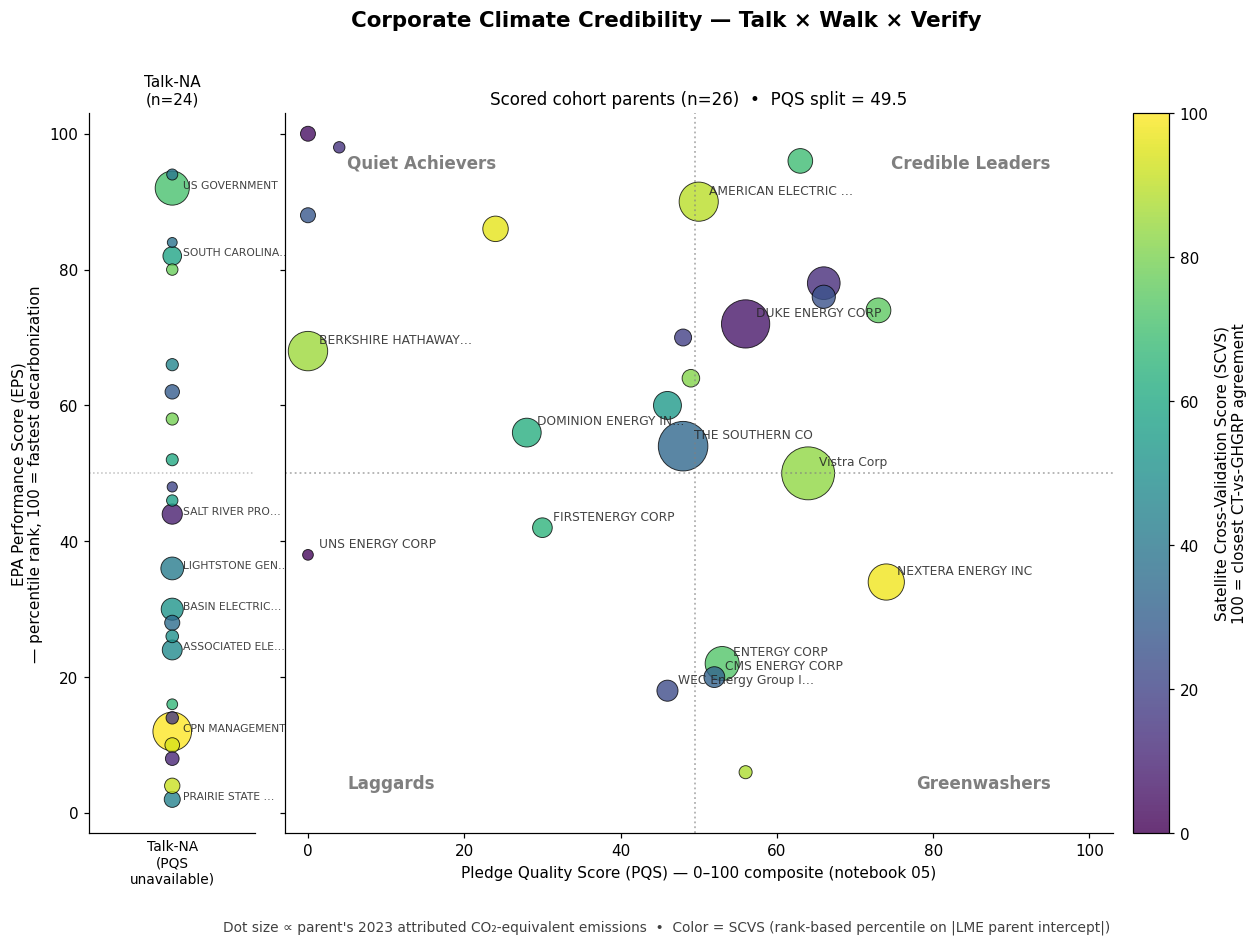


Saved: /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/outputs/figures/06_cccs_quadrant.png


In [8]:
# === 2x2 quadrant headline figure ===
# Layout: narrow Talk-NA strip on left (shared y) + main 2x2 scatter on right
fig, (ax_na, ax_main) = plt.subplots(
    1, 2, sharey=True,
    gridspec_kw={"width_ratios": [1, 6], "wspace": 0.05},
    figsize=(14, 8.5),
)

# Marker-size mapping: dot area ∝ attributed 2023 emissions (in MtCO2e)
size_min, size_max = 30, 1200
emissions_mt = df["attributed_co2e"] / 1e6  # tonnes → million tonnes for readable scale
sizes = np.interp(emissions_mt, (emissions_mt.min(), emissions_mt.max()), (size_min, size_max))

# --- Left panel: Talk-NA parents ---
mask_na = df["pqs_composite"].isna()
talk_na_df    = df[mask_na]
talk_na_sizes = sizes[mask_na]
ax_na.scatter(np.zeros(len(talk_na_df)), talk_na_df["eps_score"],
              s=talk_na_sizes, c=talk_na_df["scvs_score"], cmap="viridis",
              vmin=0, vmax=100, edgecolor="black", linewidth=0.6, alpha=0.8)
ax_na.axhline(EPS_MEDIAN, color="gray", linestyle=":", alpha=0.5, linewidth=1)
ax_na.set_xlim(-0.8, 0.8); ax_na.set_xticks([])
ax_na.set_xlabel("Talk-NA\n(PQS\nunavailable)", fontsize=9)
ax_na.set_ylabel("EPA Performance Score (EPS)\n— percentile rank, 100 = fastest decarbonization", fontsize=10)
ax_na.set_title(f"Talk-NA\n(n={len(talk_na_df)})", fontsize=10)

# --- Right panel: 2x2 quadrant scatter ---
mask_scored = ~mask_na
scored_df    = df[mask_scored]
scored_sizes = sizes[mask_scored]
sc = ax_main.scatter(scored_df["pqs_composite"], scored_df["eps_score"],
                     s=scored_sizes, c=scored_df["scvs_score"], cmap="viridis",
                     vmin=0, vmax=100, edgecolor="black", linewidth=0.6, alpha=0.8)

# Median split lines
ax_main.axvline(PQS_MEDIAN, color="gray", linestyle=":", alpha=0.6, linewidth=1.2)
ax_main.axhline(EPS_MEDIAN, color="gray", linestyle=":", alpha=0.6, linewidth=1.2)

# Quadrant text labels in corners (faint, so they don't distract)
ax_main.text(95, 97, "Credible Leaders",  ha="right",  va="top",    fontsize=11, alpha=0.5, weight="bold")
ax_main.text(5,  97, "Quiet Achievers",   ha="left",   va="top",    fontsize=11, alpha=0.5, weight="bold")
ax_main.text(95, 3,  "Greenwashers",      ha="right",  va="bottom", fontsize=11, alpha=0.5, weight="bold")
ax_main.text(5,  3,  "Laggards",          ha="left",   va="bottom", fontsize=11, alpha=0.5, weight="bold")

ax_main.set_xlim(-3, 103); ax_main.set_ylim(-3, 103)
ax_main.set_xlabel("Pledge Quality Score (PQS) — 0–100 composite (notebook 05)", fontsize=10)
ax_main.set_title(f"Scored cohort parents (n={len(scored_df)})  •  PQS split = {PQS_MEDIAN:.1f}", fontsize=11)

# Annotate top 3 emitters per quadrant by name (truncate to first 18 chars)
def short(name, n=18):
    return name[:n] + ("…" if len(name) > n else "")
for q in ["Credible Leader", "Quiet Achiever", "Greenwasher", "Laggard"]:
    sub = scored_df[scored_df["quadrant"] == q].nlargest(3, "attributed_co2e")
    for _, row in sub.iterrows():
        ax_main.annotate(short(row["parent_name"]),
                         (row["pqs_composite"], row["eps_score"]),
                         xytext=(7, 5), textcoords="offset points",
                         fontsize=8, color="#222", alpha=0.85)
# Also annotate Talk-NA parents (their names are key context)
for _, row in talk_na_df.nlargest(min(8, len(talk_na_df)), "attributed_co2e").iterrows():
    ax_na.annotate(short(row["parent_name"], 14),
                   (0, row["eps_score"]),
                   xytext=(7, 0), textcoords="offset points",
                   fontsize=7, color="#222", alpha=0.85)

# Colorbar
cbar = fig.colorbar(sc, ax=ax_main, pad=0.02, label="Satellite Cross-Validation Score (SCVS)\n100 = closest CT-vs-GHGRP agreement")

# Title + footer
fig.suptitle("Corporate Climate Credibility — Talk × Walk × Verify",
             fontsize=14, weight="bold", y=0.99)
fig.text(0.5, 0.005,
         "Dot size ∝ parent's 2023 attributed CO₂-equivalent emissions  •  Color = SCVS (rank-based percentile on |LME parent intercept|)",
         ha="center", fontsize=9, alpha=0.75)

fig.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(FIG_DIR / "06_cccs_quadrant.png", bbox_inches="tight", dpi=200)
plt.show()
print(f"\nSaved: {FIG_DIR / '06_cccs_quadrant.png'}")

## 6. Sensitivity analysis — rank stability under alternative weight schemes

For each of the 6 weight schemes defined in the methodology section, we recompute Corporate Climate Credibility Score (CCCS) for every *fully-scored* parent and record their rank (1 = best). Here "fully-scored" means a parent with all three axes present — Pledge Quality Score, EPA Performance Score, and Satellite Cross-Validation Score. The sensitivity sample is therefore the **24 parents with full CCCS** (a subset of the 26 PQS-scored parents: 2 are missing from notebook 03's LME sample and therefore have no SCVS).

We then characterize each parent's rank stability:

- **`min_rank` / `max_rank`** — best and worst rank across the 6 schemes
- **`rank_range`** — `max_rank - min_rank`; the "stability gap" (smaller = more stable across all weighting choices)
- **`always_top_quartile`** — True if the parent is in the top 25% of scored parents under all 6 schemes (robust Credible-Leader signal)
- **`always_bottom_quartile`** — True if the parent is in the bottom 25% under all 6 schemes (robust Laggard signal)

This is the auditable answer to "does this parent's headline score depend on the weighting choice".

In [ ]:
WEIGHT_SCHEMES = {
    "default":       {"pqs": 0.20, "eps": 0.40, "scvs": 0.40},
    "equal":         {"pqs": 0.3333333, "eps": 0.3333333, "scvs": 0.3333334},
    "action_heavy":  {"pqs": 0.10, "eps": 0.45, "scvs": 0.45},
    "talk_heavy":    {"pqs": 0.40, "eps": 0.30, "scvs": 0.30},
    "walk_heavy":    {"pqs": 0.20, "eps": 0.60, "scvs": 0.20},
    "verify_heavy":  {"pqs": 0.20, "eps": 0.20, "scvs": 0.60},
}

# Compute CCCS under each scheme; include only complete rows to avoid NaN ranks.
scored_mask = (
    df["pqs_composite"].notna()
    & df["eps_score"].notna()
    & df["scvs_score"].notna()
)
scored_df_ix = df[scored_mask].copy()

scheme_scores = {}
scheme_ranks  = {}
for name, w in WEIGHT_SCHEMES.items():
    scored_df_ix[f"cccs_{name}"] = scored_df_ix.apply(
        lambda r: geo_mean([r["pqs_composite"], r["eps_score"], r["scvs_score"]],
                           [w["pqs"], w["eps"], w["scvs"]]),
        axis=1,
    )
    scored_df_ix[f"rank_{name}"] = scored_df_ix[f"cccs_{name}"].rank(method="dense", ascending=False)
    scheme_scores[name] = scored_df_ix[f"cccs_{name}"]
    scheme_ranks[name]  = scored_df_ix[f"rank_{name}"]

# Rank stability metrics per parent
rank_cols = [f"rank_{n}" for n in WEIGHT_SCHEMES]
scored_df_ix["min_rank"]   = scored_df_ix[rank_cols].min(axis=1).astype("Int64")
scored_df_ix["max_rank"]   = scored_df_ix[rank_cols].max(axis=1).astype("Int64")
scored_df_ix["rank_range"] = (scored_df_ix["max_rank"] - scored_df_ix["min_rank"]).astype("Int64")

# Top/bottom quartile cutoff (count over scored parents)
n_scored = scored_mask.sum()
q1_cutoff = int(np.ceil(n_scored * 0.25))
q4_cutoff = int(np.floor(n_scored * 0.75)) + 1

scored_df_ix["always_top_quartile"]    = (scored_df_ix[rank_cols].max(axis=1) <= q1_cutoff)
scored_df_ix["always_bottom_quartile"] = (scored_df_ix[rank_cols].min(axis=1) >= q4_cutoff)

n_pqs_scored = int(df["pqs_composite"].notna().sum())
print(f"Sensitivity analysis ({len(WEIGHT_SCHEMES)} schemes × {n_scored} fully-scored parents)")
print(f"  Subset of {n_pqs_scored} PQS-scored parents; {n_pqs_scored - n_scored} are missing the LME intercept (no SCVS).")
print(f"  Top-quartile cutoff:    rank ≤ {q1_cutoff}")
print(f"  Bottom-quartile cutoff: rank ≥ {q4_cutoff}")
print()

Sensitivity analysis (6 schemes x 24 scored parents):
  Top-quartile cutoff:    rank <= 6
  Bottom-quartile cutoff: rank >= 19



In [36]:
robust_top    = scored_df_ix[scored_df_ix["always_top_quartile"]].sort_values("min_rank")
robust_bottom = scored_df_ix[scored_df_ix["always_bottom_quartile"]].sort_values("max_rank", ascending=False)

print(f"Robust Credible Leaders (top-quartile under ALL 6 schemes): {len(robust_top)} parents")
robust_top[["parent_name", "pqs_composite", "eps_score", "scvs_score", "min_rank", "max_rank", "rank_range"]]

Robust Credible Leaders (top-quartile under ALL 6 schemes): 3 parents


,parent_name,pqs_composite,eps_score,scvs_score,min_rank,max_rank,rank_range
4,AMERICAN ELECTRIC POWER CO INC,50.0,90.0,89.583333,1,3,2
13,DTE ENERGY CO,73.0,74.0,75.000000,1,4,3
14,NRG ENERGY INC,63.0,96.0,68.750000,1,4,3


In [37]:
print(f"\nRobust Laggards (bottom-quartile under ALL 6 schemes): {len(robust_bottom)} parents")
robust_bottom[["parent_name", "pqs_composite", "eps_score", "scvs_score", "min_rank", "max_rank", "rank_range"]]


Robust Laggards (bottom-quartile under ALL 6 schemes): 3 parents


,parent_name,pqs_composite,eps_score,scvs_score,min_rank,max_rank,rank_range
45,UNS ENERGY CORP,0.0,38.0,2.083333,24,24,0
30,TALEN ENERGY CORP,0.0,100.0,4.166667,22,23,1
18,WEC Energy Group Inc,46.0,18.0,22.916667,19,22,3


In [38]:
print(f"\nMost weight-sensitive parents (largest rank_range across schemes):")
sensitive = scored_df_ix.nlargest(8, "rank_range")
sensitive[["parent_name", "pqs_composite", "eps_score", "scvs_score", "min_rank", "max_rank", "rank_range"]]


Most weight-sensitive parents (largest rank_range across schemes):


,parent_name,pqs_composite,eps_score,scvs_score,min_rank,max_rank,rank_range
3,BERKSHIRE HATHAWAY INC,0.0,68.0,85.416667,10,21,11
34,CONSTELLATION ENERGY CORP,56.0,6.0,87.500000,12,23,11
6,NEXTERA ENERGY INC,74.0,34.0,97.916667,2,12,10
8,ENTERGY CORP,53.0,22.0,72.916667,8,17,9
9,XCEL ENERGY INC,66.0,78.0,12.500000,9,18,9
15,AMEREN CORP,66.0,76.0,25.000000,6,14,8
2,DUKE ENERGY CORP,56.0,72.0,6.250000,15,22,7
25,AES CORP,48.0,70.0,18.750000,10,17,7


## 7. Save deliverables

Three CSV deliverables are persisted for downstream consumption:

| File | Used by |
|---|---|
| `cohort_cccs.csv` | Working-paper findings table; headline scoreboard |
| `cohort_cccs_components.csv` | Notebook 07 dashboard — per-parent PQS / EPS / SCVS components for live slider recomputation |
| `cohort_cccs_rank_stability.csv` | Notebook 07 audit view |

In [39]:
# --- 1) Main deliverable: cohort_cccs.csv ---
main_cols = ["parent_name", "rank", "attributed_co2e", "quadrant",
             "pqs_composite", "eps_score", "scvs_score",
             "cccs_composite", "cccs_partial_composite", "cccs_rank", "cccs_partial_rank",
             "pct_per_yr", "parent_intercept"]
df_out = df[main_cols].copy()
df_out.to_csv(DATA_PROCESSED / "cohort_cccs.csv", index=False)
print(f"Wrote cohort_cccs.csv: {len(df_out)} parents × {len(main_cols)} cols")

# --- 2) Components for dashboard live-recompute ---
components_cols = ["parent_name", "rank", "attributed_co2e",
                   "pqs_composite", "eps_score", "scvs_score"]
df[components_cols].to_csv(DATA_PROCESSED / "cohort_cccs_components.csv", index=False)
print(f"Wrote cohort_cccs_components.csv: {len(df)} parents × {len(components_cols)} cols")

# --- 3) Rank stability under 6 sensitivity schemes ---
stability_cols = ["parent_name", "rank", "pqs_composite", "eps_score", "scvs_score"]
stability_cols += [f"cccs_{n}"  for n in WEIGHT_SCHEMES]
stability_cols += [f"rank_{n}"  for n in WEIGHT_SCHEMES]
stability_cols += ["min_rank", "max_rank", "rank_range",
                   "always_top_quartile", "always_bottom_quartile"]
scored_df_ix[stability_cols].to_csv(DATA_PROCESSED / "cohort_cccs_rank_stability.csv", index=False)
print(f"Wrote cohort_cccs_rank_stability.csv: {len(scored_df_ix)} scored parents × {len(stability_cols)} cols")

Wrote cohort_cccs.csv: 50 parents × 13 cols
Wrote cohort_cccs_components.csv: 50 parents × 6 cols
Wrote cohort_cccs_rank_stability.csv: 24 scored parents × 22 cols


## 8. Summary of results

In [40]:
print("=" * 72)
print("NOTEBOOK 06 — SUMMARY OF RESULTS")
print("=" * 72)
print(f"\nCohort: {len(df)} parent companies (top 50 U.S. fossil-fuel power-generating parents by 2023 EPA GHGRP attributed CO₂e)")
print(f"\nCoverage:")
print(f"  PQS scored (notebook 05):                  {df['pqs_composite'].notna().sum():2d} / {len(df)}")
print(f"  Talk-NA (no public disclosure source):     {df['pqs_composite'].isna().sum():2d} / {len(df)}")
print(f"  EPS scored (notebook 01 trajectory slopes):  {df['eps_score'].notna().sum():2d} / {len(df)}")
print(f"  SCVS scored (notebook 03 LME intercepts):    {df['scvs_score'].notna().sum():2d} / {len(df)}")
print(f"  Full CCCS scored (all three axes present):   {df['cccs_composite'].notna().sum():2d} / {len(df)}")

print(f"\nQuadrant distribution:")
print(df["quadrant"].value_counts().to_string())

print(f"\nCCCS composite (full, default weights 0.2/0.4/0.4):")
cccs = df["cccs_composite"].dropna()
print(f"  range:  [{cccs.min():.2f}, {cccs.max():.2f}]")
print(f"  median: {cccs.median():.2f}")
print(f"  mean:   {cccs.mean():.2f}")

print(f"\nRobust classification (top-quartile under ALL 6 weight schemes):")
print(f"  Robust Credible Leaders:  {scored_df_ix['always_top_quartile'].sum()} parents")
print(f"  Robust Laggards:          {scored_df_ix['always_bottom_quartile'].sum()} parents")
print(f"  Weight-sensitive parents (rank_range ≥ 5):  {(scored_df_ix['rank_range'] >= 5).sum()} parents")

print(f"\nHeadline figures saved:")
print(f"  Interactive (Plotly): {FIG_DIR / '06_cccs_quadrant.html'}")
print(f"  Static (matplotlib):  {FIG_DIR / '06_cccs_quadrant.png'}")
print("=" * 72)

NOTEBOOK 06 — SUMMARY OF RESULTS

Cohort: 50 parent companies (top 50 U.S. fossil-fuel power-generating parents by 2023 EPA GHGRP attributed CO₂e)

Coverage:
  PQS scored (notebook 05):                  26 / 50
  Talk-NA (no public disclosure source):     24 / 50
  EPS scored (notebook 01 trajectory slopes):  50 / 50
  SCVS scored (notebook 03 LME intercepts):    48 / 50
  Full CCCS scored (all three axes present):   24 / 50

Quadrant distribution:
quadrant
Talk-NA            24
Quiet Achiever     10
Credible Leader     7
Greenwasher         6
Laggard             3

CCCS composite (full, default weights 0.2/0.4/0.4):
  range:  [5.75, 79.87]
  median: 42.92
  mean:   43.92

Robust classification (top-quartile under ALL 6 weight schemes):
  Robust Credible Leaders:  3 parents
  Robust Laggards:          3 parents
  Weight-sensitive parents (rank_range ≥ 5):  11 parents

Headline figure saved:
  /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/outp